# PetFinder.my Adoption Prediction

## Multimodal Machine Learning for Adoption Speed Classification

CS4662 Advanced Machine Learning and Deep Learning, Spring 2026


## Abstract

This project predicts PetFinder.my adoption speed from structured profile metadata, free-text descriptions, and pet images. We implemented a modular pipeline covering tabular gradient boosting, text-only classification, image-only transfer learning, cached BERT and ResNet50 embeddings, and early multimodal fusion with ablation studies. The strongest model in the completed experiments is the XGBoost tabular baseline with mean 5-fold QWK of 0.3658. Deep early fusion with tabular features, BERT description embeddings, and ResNet50 image embeddings reached best validation QWK of 0.3285, improving over individual text and image pilots but not surpassing the tabular baseline. The ablation study indicates that tabular, image, and text modalities each contribute useful signal in the deep fusion setup, with image removal causing the largest observed drop.

## Reproducibility Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data import get_paths, load_test_data, load_train_data, modality_counts

paths = get_paths(root=PROJECT_ROOT)
report_dir = paths.outputs_dir / "reports"
feature_dir = paths.outputs_dir / "features"
train_df = load_train_data(paths)
test_df = load_test_data(paths)

print(f"Project root: {PROJECT_ROOT}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Train input columns: {len(train_df.columns) - 1}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(modality_counts(paths))

Project root: C:\Users\andys\Documents\4662_Project
Train rows: 14993
Test rows: 3972
Train input columns: 23
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


{'train_images': 58311, 'test_images': 14465, 'train_metadata': 58311, 'test_metadata': 14465, 'train_sentiment': 14442, 'test_sentiment': 3865}


## Dataset and Metric

The dataset contains 14,993 labeled training profiles and 3,972 test profiles. Each training row has 23 input columns covering structured metadata, identifiers, names, free-text descriptions, and image counts, plus the ordinal target `AdoptionSpeed` with five classes. Local image files are available for most training profiles. The project metric is Quadratic Weighted Kappa (QWK), which penalizes predictions more heavily when they are farther from the true adoption-speed class.

,count,percent
AdoptionSpeed,,
0,410,2.73
1,3090,20.61
2,4037,26.93
3,3259,21.74
4,4197,27.99


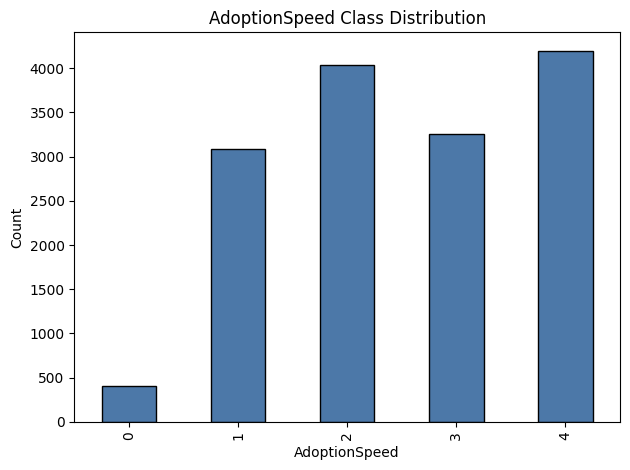

In [2]:
target_summary = pd.DataFrame({
    "count": train_df["AdoptionSpeed"].value_counts().sort_index(),
    "percent": (train_df["AdoptionSpeed"].value_counts(normalize=True).sort_index() * 100).round(2),
})
display(target_summary)

ax = target_summary["count"].plot(kind="bar", color="#4c78a8", edgecolor="black")
ax.set_title("AdoptionSpeed Class Distribution")
ax.set_xlabel("AdoptionSpeed")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Methods

### Tabular Baselines

Structured features were processed with leak-free fold-local preprocessing: missing numeric values were median-imputed and scaled, categorical codes were ordinal-encoded with unknown handling, and simple profile-derived features such as description length, color count, fee flag, video flag, and photo flag were added. XGBoost and LightGBM were evaluated with stratified 5-fold cross-validation.

### Text Models

The text-only baseline used TF-IDF n-grams with a balanced LinearSVC classifier. For fusion, we cached `bert-base-multilingual-cased` CLS embeddings for all 14,993 descriptions, producing a `(14993, 768)` feature matrix. Multilingual BERT was selected because the dataset can contain non-English text.

### Image Models

The image-only pilot trained a frozen-backbone ResNet50 classifier head on a stratified image sample. For fusion, we cached one ResNet50 embedding per pet using the first available training image and a blank-image fallback for missing images, producing a `(14993, 2048)` feature matrix.

### Multimodal Fusion

The final fusion experiment used early fusion: tabular features, BERT text embeddings, and ResNet50 image embeddings were concatenated and passed through a feed-forward PyTorch classifier. Ablations were run by zeroing one modality at a time while preserving the same train/validation split and training recipe.

## Results

In [3]:
tabular = pd.read_csv(report_dir / "tabular_baseline_cv.csv")
text = pd.read_csv(report_dir / "text_tfidf_svm_cv.csv")
image_history = pd.read_csv(report_dir / "image_resnet50_history.csv")
fusion_deep = pd.read_csv(report_dir / "fusion_deep_ablation.csv")
image_best = image_history.loc[image_history["val_qwk"].idxmax()]
fusion_full = fusion_deep.loc[fusion_deep["ablation"] == "full"].iloc[0]
final_fusion = fusion_deep.loc[fusion_deep["ablation"] == "full", [
    "run_name",
    "architecture",
    "best_qwk",
    "final_qwk",
    "final_accuracy",
    "final_val_loss",
    "epochs_ran",
]]

summary = pd.DataFrame([
    {"model": "XGBoost tabular", "result_type": "5-fold mean QWK", "qwk": tabular.loc[tabular["model"] == "XGBoost", "mean_qwk"].iloc[0]},
    {"model": "LightGBM tabular", "result_type": "5-fold mean QWK", "qwk": tabular.loc[tabular["model"] == "LightGBM", "mean_qwk"].iloc[0]},
    {"model": "TF-IDF + LinearSVC text", "result_type": "5-fold mean QWK", "qwk": text["mean_qwk"].iloc[0]},
    {"model": "ResNet50 image pilot", "result_type": "best val QWK", "qwk": image_best["val_qwk"]},
    {"model": "BERT + ResNet50 + tabular early fusion", "result_type": "best val QWK", "qwk": fusion_full["best_qwk"]},
]).sort_values("qwk", ascending=False)
summary["qwk"] = summary["qwk"].round(4)
display(summary)

,model,result_type,qwk
0,XGBoost tabular,5-fold mean QWK,0.3658
1,LightGBM tabular,5-fold mean QWK,0.3568
4,BERT + ResNet50 + tabular early fusion,best val QWK,0.3285
2,TF-IDF + LinearSVC text,5-fold mean QWK,0.2383
3,ResNet50 image pilot,best val QWK,0.1810


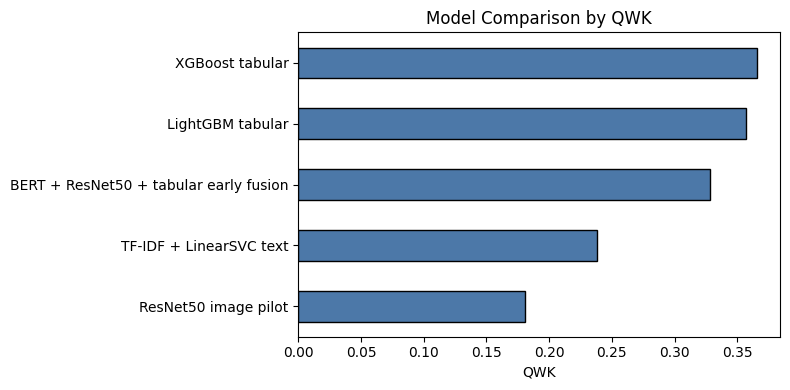

In [4]:
ax = summary.sort_values("qwk").plot(
    kind="barh",
    x="model",
    y="qwk",
    legend=False,
    color="#4c78a8",
    edgecolor="black",
    figsize=(8, 4),
)
ax.set_title("Model Comparison by QWK")
ax.set_xlabel("QWK")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Detailed Tables

In [5]:
display(tabular[["model", "mean_qwk", "std_qwk"]].round(4))
display(text[["model", "mean_qwk", "std_qwk"]].round(4))
display(image_history.round(4))
display(final_fusion.round(4))

,model,mean_qwk,std_qwk
0,XGBoost,0.3658,0.0242
1,LightGBM,0.3568,0.0206


,model,mean_qwk,std_qwk
0,TF-IDF + LinearSVC,0.2383,0.0219


,epoch,train_loss,val_loss,val_qwk
0,1.0,1.6248,1.6038,0.0936
1,2.0,1.4884,1.5987,0.1373
2,3.0,1.4249,1.5848,0.1810


,run_name,architecture,best_qwk,final_qwk,final_accuracy,final_val_loss,epochs_ran
0,fusion_early_deep_full,early,0.3285,0.2694,0.3771,2.9022,10


## Ablation Study

,ablation,blocked_modalities,best_qwk,final_qwk,final_accuracy,delta_vs_full
0,full,NaN,0.3285,0.2694,0.3771,0.0000
1,no_tabular,tabular,0.2879,0.2688,0.3421,-0.0407
2,no_image,image,0.2667,0.2442,0.3244,-0.0618
3,no_text,text,0.2869,0.2273,0.3111,-0.0416


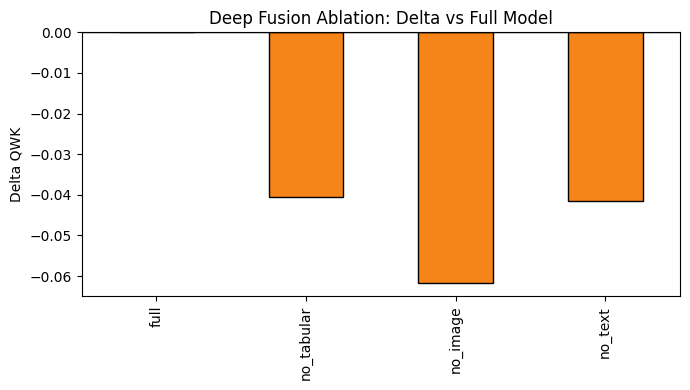

In [6]:
ablation_table = fusion_deep[[
    "ablation",
    "blocked_modalities",
    "best_qwk",
    "final_qwk",
    "final_accuracy",
    "delta_vs_full",
]].copy()
display(ablation_table.round(4))

ax = ablation_table.set_index("ablation")["delta_vs_full"].plot(
    kind="bar",
    color="#f58518",
    edgecolor="black",
    figsize=(7, 4),
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Deep Fusion Ablation: Delta vs Full Model")
ax.set_ylabel("Delta QWK")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Discussion

The tabular baseline remains the strongest model in the completed experiment set. This is plausible for PetFinder because adoption speed is strongly tied to structured profile attributes such as age, breed, vaccination status, fee, state, photo count, and profile completeness. The deep early-fusion model improved over the image-only and text-only pilots but did not surpass XGBoost.

The ablation results are more encouraging than the lightweight fusion run. Removing tabular features reduced best QWK by about 0.0407, removing text reduced QWK by about 0.0416, and removing image embeddings reduced QWK by about 0.0618. This suggests that all three modalities contain signal under the BERT + ResNet50 fusion setup, even though the frozen-feature fusion head and training recipe did not beat gradient boosting.

The main limitation is that the BERT and ResNet50 components were used as frozen feature extractors. We did not fine-tune BERT end to end, aggregate multiple images per pet beyond the first-image representation, or tune fusion hyperparameters extensively. The image-only pilot also ran for only three epochs, so its result should be interpreted as a pipeline validation rather than a final image model.

## Conclusion

The project delivered a modular multimodal pipeline and produced reproducible results for tabular, text, image, and fusion models. The strongest score in these experiments is the XGBoost tabular baseline at 0.3658 mean QWK. Deep fusion with BERT and ResNet50 embeddings reached 0.3285 best validation QWK and showed positive modality contributions in ablation, but it needs stronger modality fine-tuning and fusion optimization before it can outperform the tabular baseline.